# M3: obična RNN

Ova sveska trenira i ocenjuje M3 RNN nad sekvencama prethodno odigranih mečeva.

Svaka rekurentna arhitektura ima svoju svesku,
nezavisno od druge dve, da bi se moglo raditi paralelno bez sudara u istom
`.ipynb` fajlu. Sve tri dele istu arhitekturu (`models.MatchPredictor`) i istu
petlju treniranja (`train.train_model`) - razlikuje se samo parametar `cell`.

Skup podataka se može preuzeti sa [ove](https://www.kaggle.com/datasets/nathanlauga/nba-games) adrese.


## Priprema

In [1]:
import sys
sys.path.append("..")

import joblib
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch.utils.data import DataLoader

from src.config import MODELS_PATH, PROCESSED_DATA_PATH, RANDOM_STATE, RESULTS_FILE
from src import evaluate, models, plotting, sequences, train

train.set_seed(RANDOM_STATE)


## Učitavanje sekvenci

Iste `sekvence.npz` i iste `train`/`validation` pozicije kao u svesci 02/03 - isti mečevi kao za M0/M1, kako bi poredjenje bilo pošteno. 

In [2]:
splits = np.load(PROCESSED_DATA_PATH / "sekvence.npz")
home_sequences, away_sequences = splits["home_sequences"], splits["away_sequences"]
context, labels = splits["context"], splits["labels"]
train_idx, validation_idx = splits["train"], splits["validation"]

home_train, away_train = home_sequences[train_idx], away_sequences[train_idx]
context_train, y_train = context[train_idx], labels[train_idx]

home_val, away_val = home_sequences[validation_idx], away_sequences[validation_idx]
context_val, y_val = context[validation_idx], labels[validation_idx]

home_train.shape, context_train.shape


((18092, 10, 8), (18092, 24))

## Dataset i DataLoader

`shuffle=True` ovde meša samo redosled kojim mreža vidi već-fiksirane trening mečeve unutar jedne epohe - ne dira podelu na skupove, koja je hronološka i fiksirana još u svesci 02. Validacija se ne meša, jer se na njoj ne trenira.

In [3]:
BATCH_SIZE = 64

dataset_train = sequences.MatchSequenceDataset(home_train, away_train, context_train, y_train)
dataset_val = sequences.MatchSequenceDataset(home_val, away_val, context_val, y_val)

loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)

len(dataset_train), len(dataset_val)


(18092, 2624)

## Izbor hiperparametara

Vrednosti se biraju **pre** treniranja, jer sve što sledi zavisi od njih. Pretražuje se mreža iz `config.py` (`HIDDEN_SIZE_GRID`, `DROPOUT_GRID`, `LEARNING_RATE_GRID`) - ista mreža vrednosti za sve tri rekurentne arhitekture, dogovorena unapred, da bi poređenje M3/M4/M5 ostalo pošteno.

Pretragu izvodi `train.search_hyperparameters`, razlikuje se samo parametar `cell`.

Izbor ide po `roc_auc` na validaciji, jednim semenom.

In [4]:
rezultati_pretrage = train.search_hyperparameters(
    loader_train, loader_val,
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="rnn",
)

rezultati_pretrage.head(5).round(4)


,hidden_size,dropout,learning_rate,tacnost,roc_auc,log_loss,brier
0,64,0.15,0.003,0.6585,0.6974,0.6170,0.2140
1,128,0.00,0.003,0.6578,0.6973,0.6172,0.2140
2,128,0.30,0.001,0.6604,0.6973,0.6174,0.2143
3,128,0.15,0.001,0.6559,0.6972,0.6173,0.2142
4,64,0.30,0.003,0.6601,0.6969,0.6173,0.2142


In [5]:
najbolji = rezultati_pretrage.iloc[0]

print(f"hidden_size   {int(najbolji['hidden_size'])}")
print(f"dropout       {najbolji['dropout']}")
print(f"learning_rate {najbolji['learning_rate']}")
print(f"roc_auc       {najbolji['roc_auc']:.4f}")


hidden_size   64
dropout       0.15
learning_rate 0.003
roc_auc       0.6974


## Kreiranje mreže

`cell="rnn"` daje M3 RNN.

`MatchPredictor` obrađuje sekvencu domaćina i sekvencu gosta **istom** ćelijom (deljene težine), uzima poslednje skriveno stanje svake kao naučeni sažetak forme, nalepi ih uz kontekst i propusti kroz jedan linearni sloj do sirovog logita.

In [6]:
train.set_seed(RANDOM_STATE)

model_rnn = models.MatchPredictor(
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="rnn",
    hidden_size=int(najbolji["hidden_size"]),
    dropout=float(najbolji["dropout"]),
)
model_rnn


MatchPredictor(
  (encoder): RNN(8, 64, batch_first=True)
  (dropout): Dropout(p=0.15, inplace=False)
  (output): Linear(in_features=152, out_features=1, bias=True)
)

## Treniranje mreže

In [7]:
history = train.train_model(
    model_rnn, loader_train, loader_val,
    epochs=100, patience=5, learning_rate=float(najbolji["learning_rate"]),
)

best_epoch = int(np.argmin(history["valid_loss"]))
print(f"trenirano {len(history['train_loss'])} epoha (rano zaustavljanje)")
print(
    f"najbolja epoha: {best_epoch + 1}, "
    f"validacija gubitak {history['valid_loss'][best_epoch]:.4f}, "
    f"validacija tacnost {history['valid_accuracy'][best_epoch]:.4f}"
)


trenirano 10 epoha (rano zaustavljanje)
najbolja epoha: 5, validacija gubitak 0.6170, validacija tacnost 0.6585


## Krive učenja

Puna linija je trening, isprekidana validacija. Rastojanje između njih koje raste kroz epohe je znak overfitovanja — mreža pamti trening umesto da uči opšti obrazac. Tačka gde se validacioni gubitak prestaje popravljati (epoha 5) je i tačka u kojoj su sačuvane konačne težine.

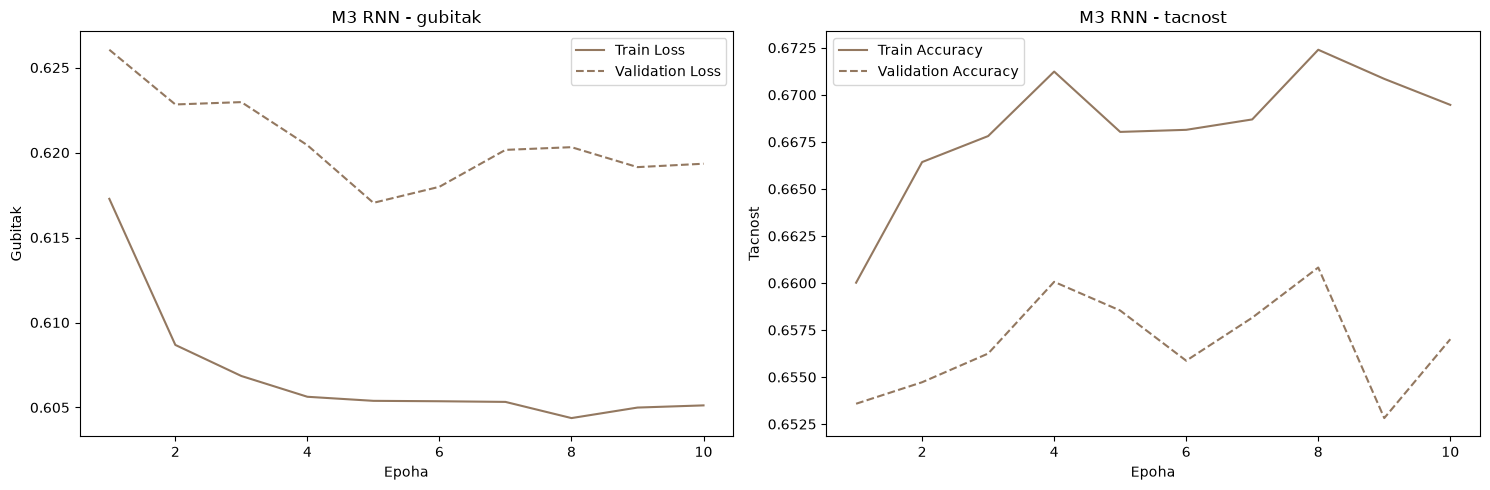

In [8]:
plotting.plot_learning_curves(history, "M3 RNN")


## Evaluacija

Matrica konfuzije i kalibracija na validaciji, metrike u `reports/rezultati.csv` — isti obrazac kao za M0/M1 u svesci 03. Test skup se ne dodiruje ovde.

In [9]:
for skup, loader in [("trening", loader_train), ("validacija", loader_val)]:
    y_proba, y_true = train.predict_proba(model_rnn, loader)
    metrike = evaluate.compute_metrics(y_true, y_proba)
    evaluate.append_results("M3 RNN", skup, metrike)

pd.read_csv(RESULTS_FILE)


,model,skup,tacnost,roc_auc,log_loss,brier
0,M0 domacin,trening,0.599547,0.500000,14.433798,0.400453
1,M0 domacin,validacija,0.588796,0.500000,14.821304,0.411204
2,M1 log. reg.,trening,0.672452,0.714898,0.601936,0.207725
3,M1 log. reg.,validacija,0.656250,0.695323,0.620364,0.215363
4,M2 XGBoost,trening,0.683285,0.731819,0.590845,0.202875
5,M2 XGBoost,validacija,0.657774,0.698829,0.616906,0.213846
6,M3 RNN,trening,0.673281,0.714217,0.602742,0.208053
7,M3 RNN,validacija,0.658537,0.697448,0.617042,0.214006


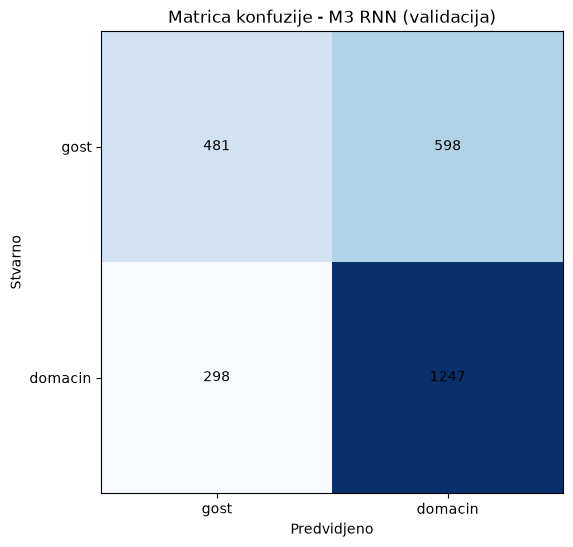

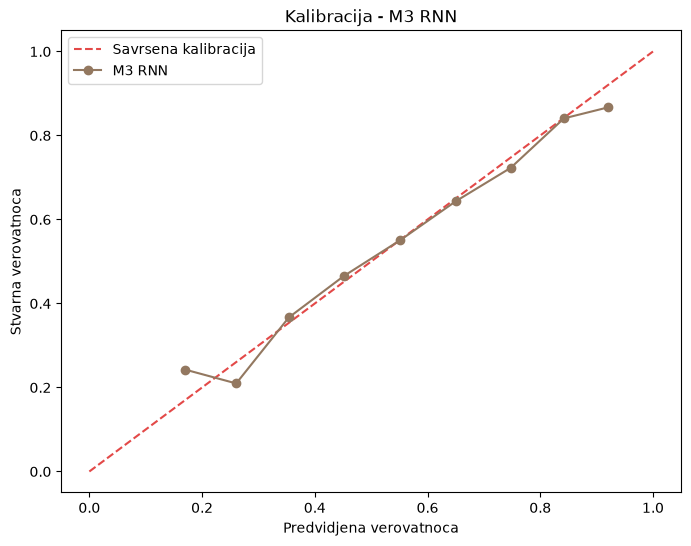

In [10]:
y_proba_val, y_true_val = train.predict_proba(model_rnn, loader_val)
y_pred_val = (y_proba_val >= 0.5).astype(int)

evaluate.plot_confusion_matrix(y_true_val, y_pred_val, "Matrica konfuzije - M3 RNN (validacija)")
evaluate.plot_calibration_curve(y_true_val, y_proba_val, "M3 RNN")


Model bolje prepoznaje pobede domaćina (81% recall) nego pobede gosta (45% recall) — posledica neravnoteže klasa (~59% pobeda domaćina u treningu), ne greška u arhitekturi. Kalibracija dobro prati dijagonalu u srednjem opsegu, uz blagu prekomernu samouverenost kod najviših predviđenih verovatnoća (~0.92 predviđeno naspram ~0.87 stvarno).

## Čuvanje modela

Propozicije traže da se sačuvaju istrenirani modeli **i** propratni skaleri. Čuva se stanje sa najmanjim validacionim gubitkom, ne poslednje stanje.

In [11]:
train.save_model(model_rnn, "rnn.pt")


## Zaključak

M3 (obična RNN) dostiže 65.9% tačnosti na validaciji (ROC-AUC 0.697, log-loss 0.617, Brier 0.214) — praktično identično M1 logističkoj regresiji iz sveske 03 (65.6%, 0.695, 0.620, 0.215). Ovo je očekivan, ne razočaravajuć rezultat: plan projekta je unapred predvideo da snaga tima u toku sezone menja malo iz meča u meč, pa pokretni prosek (M1) već hvata skoro sav dostupan signal - sekvenci ostaje malo prostora da doda nešto preko toga.

Pretraga hiperparametara bira `hidden_size=64`, `dropout=0.15`, `learning_rate=0.003` po `roc_auc` na validaciji.

Krive učenja pokazuju da se mreža skoro sva nauči u prve 2-3 epohe, posle čega se trening i validacija stabilizuju uz mali, konstantan razmak — nema znakova ozbiljnog overfitovanja, rano zaustavljanje (epoha 5 od 10) je uhvatilo šum, ne stvaran nastavak poboljšanja. Matrica konfuzije otkriva asimetriju, posledicu neravnoteže klasa: model prepoznaje 81% pobeda domaćina naspram samo 45% pobeda gosta. 

Model je sačuvan u `models/rnn.pt`.